In [48]:
#%matplotlib widget
import matplotlib.pyplot as plt
import arbin_data_reader_mio_2 as reader
import numpy as np
import os
import cProfile
import pstats
import io

In [69]:
path = './Abi_SnuG_3070_115mg_NaPF6_TEGDME_CG2.xls' #ingresar el path de su archivo
data = reader.arbin_data(path, 0.324)

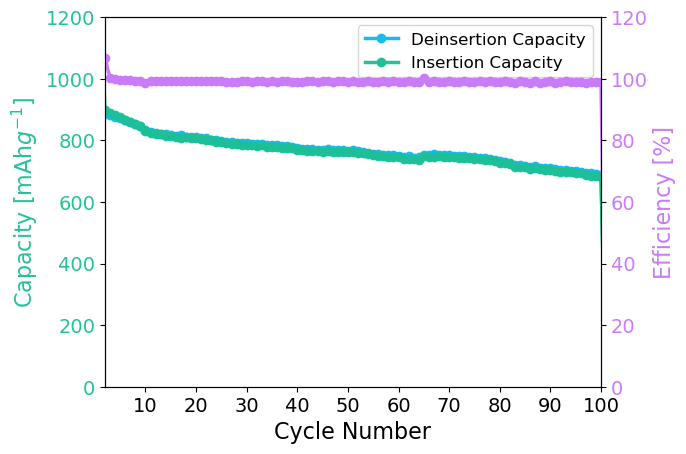

In [70]:
fig, ax = plt.subplots()
data.final_cap_plot(ax=ax, max_cy_number=100, max_eff=120, max_cap=1200)#, max_cap=1100, loc='lower left')
# plt.savefig('Cicla_cap_eff.png')
os.makedirs('./Plots', exist_ok=True)
# Obtener el nombre del archivo sin extensión
nombre_archivo = os.path.splitext(os.path.basename(path))[0]
# Crear nombre automático del gráfico
nombre_grafico1 = f'{nombre_archivo}_Cicla_cap_eff.png'
# Guardar figura
plt.savefig(f'./Plots/{nombre_grafico1}', dpi=300, bbox_inches='tight')
plt.show()

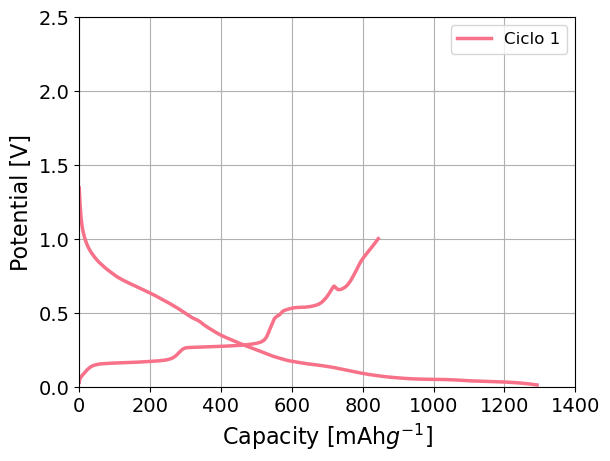

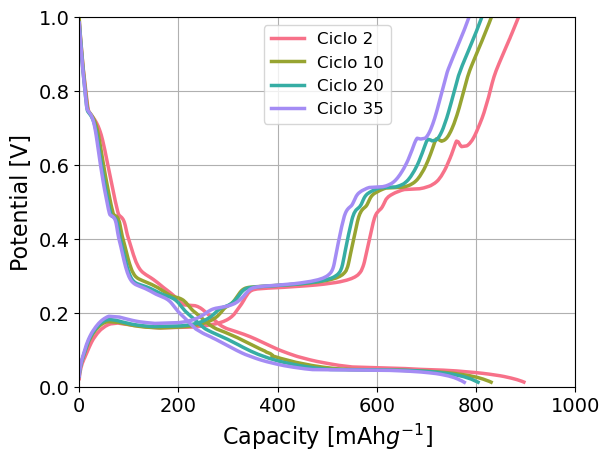

In [71]:
# ---------- 1º ciclo ----------
fig, ax = plt.subplots()
data.cicle_cap_plot(ciclos=[1], ax=ax, max_potential=2.5, max_cap=1400)
nombre_grafico2a = f'{nombre_archivo}_Perfil_ciclo1.png'
plt.savefig(f'./Plots/{nombre_grafico2a}', dpi=300, bbox_inches='tight')
plt.show()

# ---------- Otros ciclos ----------
fig, ax = plt.subplots()
data.cicle_cap_plot(ciclos=[2, 10, 20, 35], ax=ax, max_potential=1, max_cap=1000)
nombre_grafico2b = f'{nombre_archivo}_Perfiles.png'
plt.savefig(f'./Plots/{nombre_grafico2b}', dpi=300, bbox_inches='tight')
plt.show()

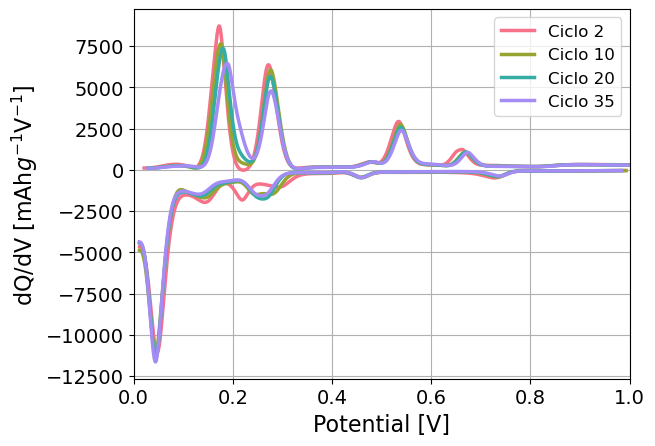

In [72]:
fig, ax = plt.subplots()
data.dqdv_plot(ciclos=[2, 10, 20, 35], alpha=6, raleo=1, ax=ax, max_plot=1)
# ax.set_ylim(-4000, 4000)
# plt.savefig('Cicla_dQdV.png')
nombre_grafico3 = f'{nombre_archivo}_dQdV.png'
plt.savefig(f'./Plots/{nombre_grafico3}', dpi=300, bbox_inches='tight')
plt.show()

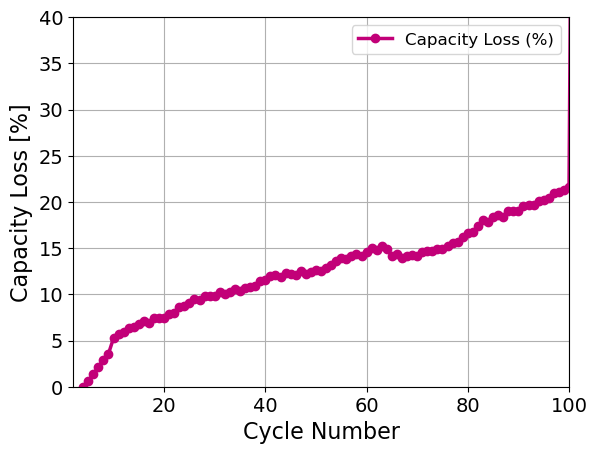

In [74]:
fig, ax = plt.subplots()
data.capacity_lost_plot(ax=ax, max_cy_number=100, max_cap_loss=40)
nombre_grafico4 = f'{nombre_archivo}_capacity-loss.png'
plt.savefig(f'./Plots/{nombre_grafico4}', dpi=300, bbox_inches='tight')
plt.show()

In [107]:
archivos = ['Abi_SnKJB_3070_108mg_NaPF6_TEGDME_CG2.xls', 'Abi_SnKJB_3070_030_NaPF6_TEGDME_CG2.xls']
#archivos = ['Abi_SnuG_3070_115mg_NaPF6_TEGDME_CG2.xls', 'Abi_SnuG_3070_0504mg_NaPF6_TEGDME_CG1.xls']#, 'VB_SnuG_178mg_NaPF6_TEGDME_Crate_15-07-25.xls', 'AR_SnG_178mg_NaPF6_TEGDME_Crate2.xls']
masa = [0.324, 0.30]
datasets = [reader.arbin_data(archivo, m) for archivo, m in zip(archivos, masa)]
labels = ['SnKJB i: 0.16A/g', 'SnKJB i: 0.05A/g']#, 'masa: 1.78mg', 'masa: 1.78mg bis']

<Axes: xlabel='Cycle Number', ylabel='Capacity [mAh$g^{-1}$]'>

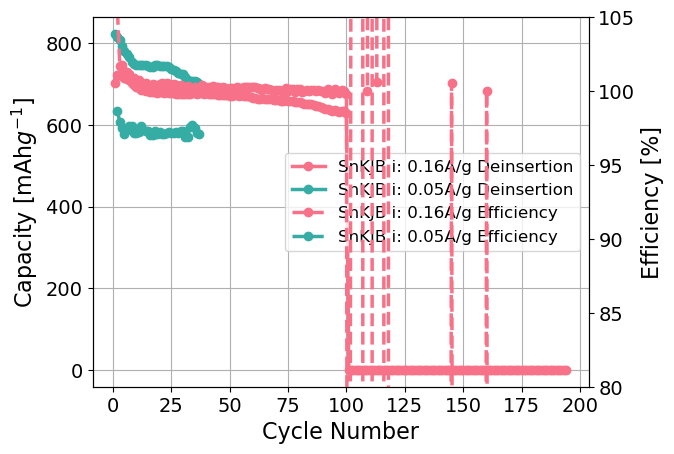

In [108]:
reader.plot_multi_final_cap(datasets, labels=labels)

<Axes: xlabel='Cycle Number', ylabel='Capacity Loss [%]'>

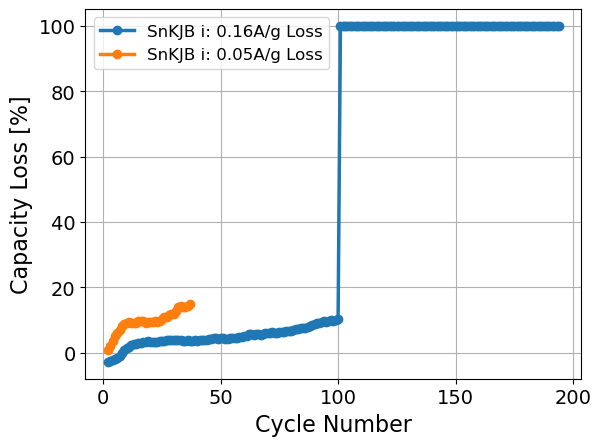

In [109]:
reader.plot_multi_capacity_loss(datasets, labels=labels)

<Axes: xlabel='Potential [V]', ylabel='dQ/dV [mAh$g^{-1}$V$^{-1}$]'>

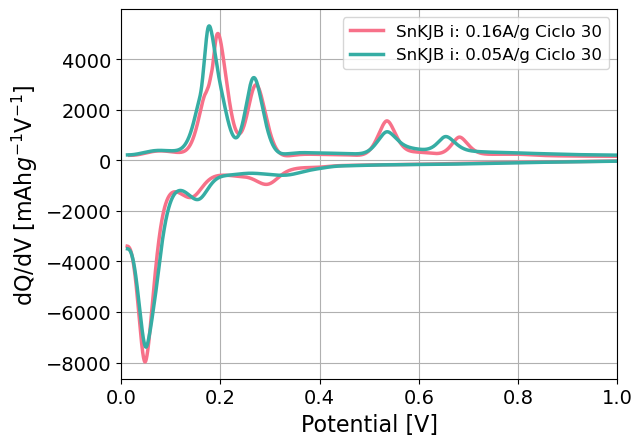

In [114]:
reader.plot_multi_dqdv(datasets, labels=labels, ciclos=[30], alpha=6, raleo=2)